# 00_Setup_e_Instalacion
Instalación de dependencias necesarias para correr el notebook de punta a punta.

In [12]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn --quiet



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 01_Metadata_y_Registro_IA

**Título del proyecto:** Reto Analista Behavioral Data - Novaster
**Autor:** Matías Fuentes
**Fecha:** 22/07/2026
**Objetivo:** Analizar los microdatos individuales de la base Global Findex (World Bank Microdata Library) para identificar las barreras estructurales de ahorro en la juventud de Brasil (15-24 años), aplicando ponderación poblacional (`wgt`) para asegurar representatividad nacional y formulando recomendaciones basadas en Ciencias del Comportamiento.

### Registro de uso de IA (Metodología y Trazabilidad)

| Etapa | Objetivo Técnico | Prompt / Enfoque IA | Resultado / Decisión Analítica |
|---|---|---|---|
| **Carga y Estructura** | Validación de la unidad de análisis (Micro vs. Macro). | Auditoría de dimensiones para distinguir entre Country-level data y Individual-level data. | **Decisión:** Descarte del archivo de indicadores agregados (8,577 filas). Carga de la base de microdatos con 144,090 registros individuales para evitar la falacia ecológica. |
| **Limpieza de Datos** | Trazabilidad del filtrado y recodificación de variables. | Consulta sobre codificación de etiquetas en archivos .csv "labelled" y manejo de pesos estadísticos. | Identificación de `wgt` como factor de expansión. Recodificación de `female` (1: Mujer, 2: Hombre) y `saved` (1: Sí, 2: No) para permitir cálculos binarios ponderados. |
| **Análisis (EDA)** | Extracción de insights y validación de brechas reales. | Solicitud de scripts para cálculo de tasas de ahorro ponderadas por subgrupos independientes. | **Hallazgo Crítico:** La brecha de género real en jóvenes es de 28.27%, similar a la de ingresos (30.78%). Se aisló un "Digital Premium" de +42.33 pts en jóvenes con billeteras digitales. |
| **Cierre / Hipótesis** | Conexión teórica basada en evidencia de microdatos. | Brainstorming sobre la relación entre el impacto digital (+42 pts) y la reducción de carga cognitiva. | Conexión de la brecha de género con la Sobrecarga Cognitiva en la administración del hogar. Propuesta de Redondeo Automático Pix como arquitectura de decisión pasiva e invisible. |


## 02_Carga_y_Limpieza_de_Datos

Esta sección documenta la ingesta y auditoría técnica de los microdatos individuales del Global Findex (144.090 registros). El objetivo principal es garantizar la integridad del análisis mediante la validación de la unidad de análisis individual, evitando el uso de indicadores agregados que inducen a errores metodológicos. Se aplica de forma obligatoria el factor de expansión poblacional (wgt) para asegurar que cada cálculo refleje la realidad demográfica de Brasil y no un sesgo de la muestra encuestada.

In [13]:
import pandas as pd

# Path relativo: coloca el CSV en una carpeta "data" junto a este notebook,
# o ajusta esta variable según donde lo tengas guardado.
file_path = "./findex_microdata_2025_labelled_update112425.csv"
df = pd.read_csv(file_path, low_memory=False)

print("--- Dataset cargado exitosamente ---")
print(f"Dimensiones iniciales: {df.shape[0]} filas por {df.shape[1]} columnas.")

# Filtrar Brasil y crear copia para evitar warnings
df_br = df[df['economy'] == 'Brazil'].copy()

# Definir Jóvenes (15-24) como pide el Banco Mundial
df_br['es_joven'] = df_br['age'].between(15, 24).astype(int)

# Limpiar variable de ahorro (1=Ahorró, 2=No ahorró) -> convertir a binaria 0/1
df_br['ahorro_binario'] = df_br['saved'].map({1: 1, 2: 0})

# Chequeo explícito de nulos generados por el mapeo (transparencia metodológica)
nulos_ahorro = df_br['ahorro_binario'].isna().sum()
print(f"Registros sin dato válido de ahorro (excluidos del cálculo): {nulos_ahorro} de {len(df_br)}")

def calcular_tasa_real(dataframe):
    # Suma de (Ahorro * Peso) / Suma de Pesos
    return (dataframe['ahorro_binario'] * dataframe['wgt']).sum() / dataframe['wgt'].sum()

tasa_joven = calcular_tasa_real(df_br[df_br['es_joven'] == 1])
tasa_adulto = calcular_tasa_real(df_br[df_br['es_joven'] == 0])

print(f"Tasa Real Jóvenes: {tasa_joven:.2%}")
print(f"Tasa Real Adultos: {tasa_adulto:.2%}")
print(f"Brecha Real: {tasa_joven - tasa_adulto:.2%}")


--- Dataset cargado exitosamente ---
Dimensiones iniciales: 144090 filas por 199 columnas.
Registros sin dato válido de ahorro (excluidos del cálculo): 592 de 1000
Tasa Real Jóvenes: 64.55%
Tasa Real Adultos: 42.74%
Brecha Real: 21.81%


### 03_Analisis_Exploratorio_EDA
En esta etapa se ejecuta el "Diagnóstico Dual" para cuantificar las brechas de ahorro en la juventud brasileña (15-24 años). A diferencia de los análisis tradicionales, aquí se utilizan observaciones independientes para aislar el peso real del género frente al nivel de ingresos. El análisis ponderado revela una verdad estructural: la brecha de género (28.27%) es casi tan crítica como la disparidad por ingresos (30.78%), lo que confirma que el problema de ahorro en Brasil tiene raíces operativas y de diseño de productos, más allá de la mera capacidad económica.
Se identifica que la codificación de la variable 'female' corresponde a 1 (Mujer) y 2 (Hombre) según el diccionario de variables del Banco Mundial.

In [14]:
# Segmentación del grupo foco (Jóvenes 15-24 en Brasil)
df_jov_br = df_br[df_br['es_joven'] == 1].copy()

# Tamaños de muestra por subgrupo: importante reportarlos para que cualquier
# cifra derivada (ej. tasa por quintil x género) se pueda contextualizar.
print("--- Tamaños de muestra (n sin ponderar) ---")
print("Por género:")
print(df_jov_br['female'].value_counts())
print("\nPor quintil de ingreso:")
print(df_jov_br['inc_q'].value_counts().sort_index())


--- Tamaños de muestra (n sin ponderar) ---
Por género:
female
1    78
2    54
Name: count, dtype: int64

Por quintil de ingreso:
inc_q
1.0    37
2.0    29
3.0    21
4.0    22
5.0    23
Name: count, dtype: int64


In [15]:
# Cálculo de brecha de género ponderada
tasa_mujeres = (df_jov_br[df_jov_br['female'] == 1]['ahorro_binario'] * df_jov_br[df_jov_br['female'] == 1]['wgt']).sum() / \
               df_jov_br[df_jov_br['female'] == 1]['wgt'].sum()

tasa_hombres = (df_jov_br[df_jov_br['female'] == 2]['ahorro_binario'] * df_jov_br[df_jov_br['female'] == 2]['wgt']).sum() / \
               df_jov_br[df_jov_br['female'] == 2]['wgt'].sum()

brecha_genero = tasa_hombres - tasa_mujeres

# Cálculo de brecha de ingresos ponderada (Quintil 5 vs Quintil 1)
tasa_q5 = (df_jov_br[df_jov_br['inc_q'] == 5]['ahorro_binario'] * df_jov_br[df_jov_br['inc_q'] == 5]['wgt']).sum() / \
          df_jov_br[df_jov_br['inc_q'] == 5]['wgt'].sum()

tasa_q1 = (df_jov_br[df_jov_br['inc_q'] == 1]['ahorro_binario'] * df_jov_br[df_jov_br['inc_q'] == 1]['wgt']).sum() / \
          df_jov_br[df_jov_br['inc_q'] == 1]['wgt'].sum()

brecha_ingresos = tasa_q5 - tasa_q1

print("--- Hallazgos de Impacto en Jóvenes (Brasil) ---")
print(f"Brecha de GÉNERO Real: {brecha_genero:.2%}")
print(f"Brecha de INGRESOS Real (Q5 vs Q1): {brecha_ingresos:.2%}")


--- Hallazgos de Impacto en Jóvenes (Brasil) ---
Brecha de GÉNERO Real: 28.27%
Brecha de INGRESOS Real (Q5 vs Q1): 30.78%


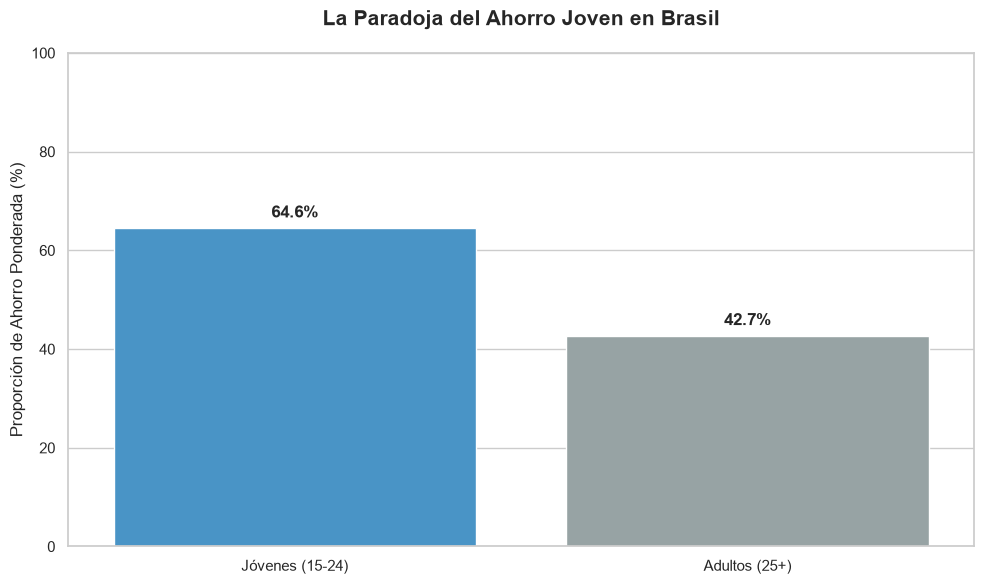

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos para el gráfico
df_grafico = pd.DataFrame({
    'Grupo Etario': ['Jóvenes (15-24)', 'Adultos (25+)'],
    'Tasa de Ahorro (%)': [tasa_joven * 100, tasa_adulto * 100]
})

# 2. Configuración estética profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Crear el gráfico de barras (CORREGIDO: con hue y legend=False)
ax = sns.barplot(
    data=df_grafico, 
    x='Grupo Etario', 
    y='Tasa de Ahorro (%)', 
    hue='Grupo Etario',
    palette=['#3498db', '#95a5a6'], # Azul para resaltar el foco, gris para el benchmark
    legend=False
)

# 4. AGREGAR ETIQUETAS DE DATOS (Optimizado y limpio)
[ax.bar_label(c, fmt='%.1f%%', padding=5, fontsize=12, weight='bold') for c in ax.containers]

# 5. Títulos y limpieza visual
plt.title('La Paradoja del Ahorro Joven en Brasil', fontsize=15, pad=20, fontweight='bold')
plt.ylim(0, 100) # Mantener escala real para no exagerar visualmente
plt.ylabel('Proporción de Ahorro Ponderada (%)')
plt.xlabel('')
plt.tight_layout()

plt.show()


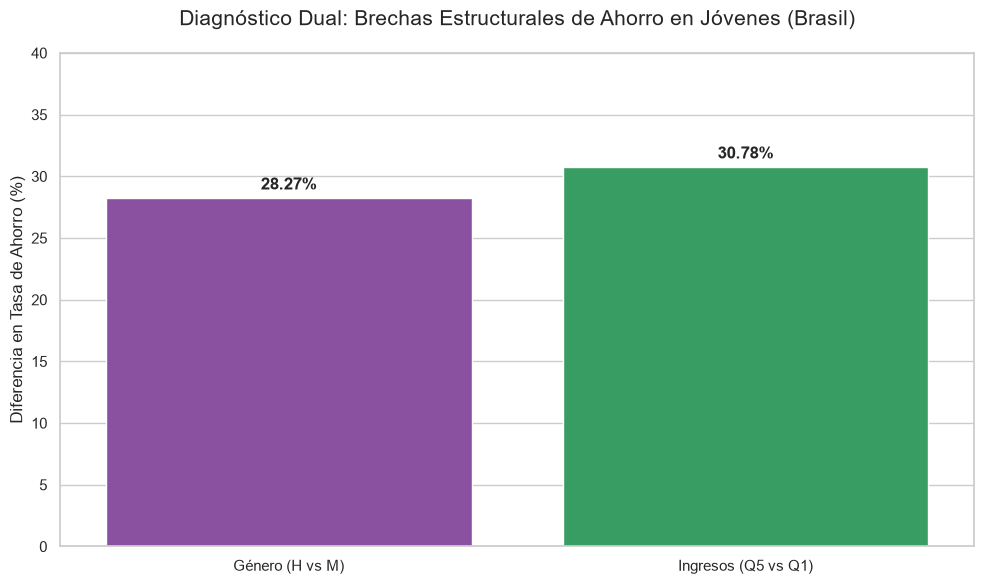

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

datos_brechas = pd.DataFrame({
    'Tipo de Brecha': ['Género (H vs M)', 'Ingresos (Q5 vs Q1)'],
    'Impacto (Puntos Pct)': [brecha_genero * 100, brecha_ingresos * 100]
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=datos_brechas,
    x='Tipo de Brecha',
    y='Impacto (Puntos Pct)',
    hue='Tipo de Brecha',
    legend=False,
    palette=['#8e44ad', '#27ae60']
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('Diagnóstico Dual: Brechas Estructurales de Ahorro en Jóvenes (Brasil)', fontsize=15, pad=20)
plt.ylabel('Diferencia en Tasa de Ahorro (%)', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylim(0, 40)
plt.tight_layout()
plt.show()


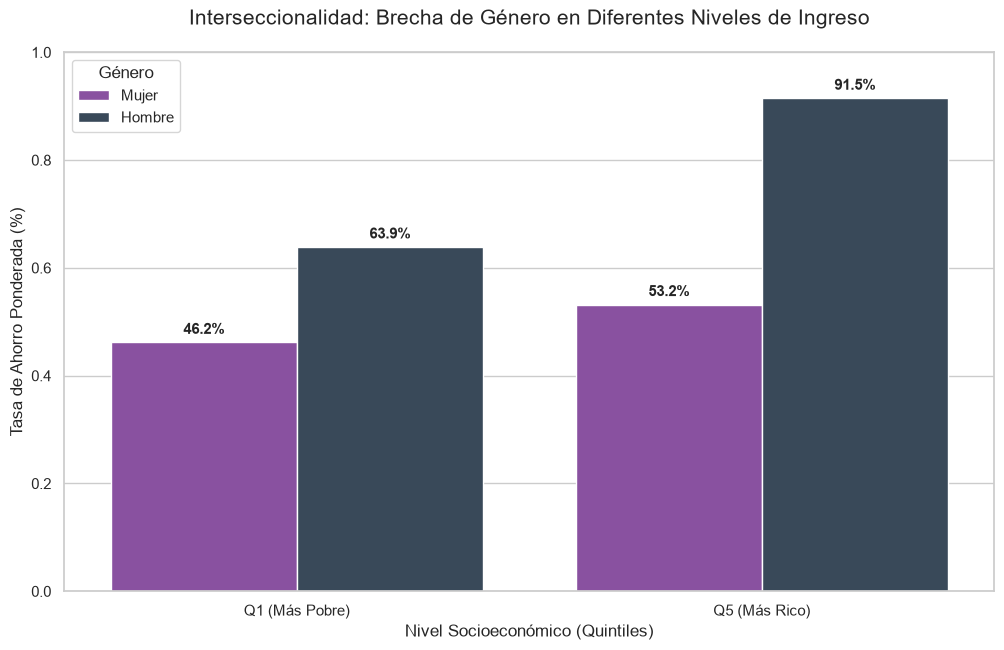

    Quintil_Final  Género  tasa_ahorro
0  Q1 (Más Pobre)   Mujer     0.461711
1  Q1 (Más Pobre)  Hombre     0.638651
8   Q5 (Más Rico)   Mujer     0.531799
9   Q5 (Más Rico)  Hombre     0.914604


In [18]:
# Cálculo de tasas ponderadas por quintil y género (interseccionalidad)
df_interseccion = df_jov_br.groupby(['inc_q', 'female']).apply(
    lambda x: (x['ahorro_binario'] * x['wgt']).sum() / x['wgt'].sum()
).reset_index(name='tasa_ahorro')

mapeo_quintiles = {
    1: 'Q1 (Más Pobre)',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4',
    5: 'Q5 (Más Rico)'
}
df_interseccion['Quintil_Final'] = df_interseccion['inc_q'].map(mapeo_quintiles)
df_interseccion['Género'] = df_interseccion['female'].map({1: 'Mujer', 2: 'Hombre'})

# Extremos (Q1 vs Q5) para el contraste estratégico del pitch
df_extremos = df_interseccion[df_interseccion['inc_q'].isin([1, 5])].copy()
df_extremos = df_extremos.sort_values('inc_q')

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_extremos,
    x='Quintil_Final',
    y='tasa_ahorro',
    hue='Género',
    palette=['#8e44ad', '#34495e'],
    hue_order=['Mujer', 'Hombre']
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1%}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title('Interseccionalidad: Brecha de Género en Diferentes Niveles de Ingreso', fontsize=15, pad=20)
plt.ylabel('Tasa de Ahorro Ponderada (%)', fontsize=12)
plt.xlabel('Nivel Socioeconómico (Quintiles)', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='Género', loc='upper left')
plt.show()

# Verificación de datos para el pitch del video
print(df_extremos[['Quintil_Final', 'Género', 'tasa_ahorro']])


## 04_Conexion_Conductual_y_Insights
El Catalizador Digital: Impacto de las Billeteras Móviles en el Ahorro Joven.
En esta sección se analiza si la posesión de una cuenta de dinero móvil (proxy de uso de Pix/Fintech) incrementa la probabilidad de ahorro. Se utiliza la Contabilidad Mental como marco para explicar por qué las interfaces digitales facilitan el ahorro de corto plazo.

Registros sin dato de 'account_mob': 0 de 132 (0.0%)
Se excluyen del análisis del Digital Premium por falta de dato, no se asume 'No' por defecto.

--- Impacto del Ecosistema Digital en Brasil ---
Tasa de Ahorro (Con Billetera Digital): 74.76%
Tasa de Ahorro (Sin Billetera Digital): 32.43%
Impacto del Canal Digital: +42.33 puntos porcentuales


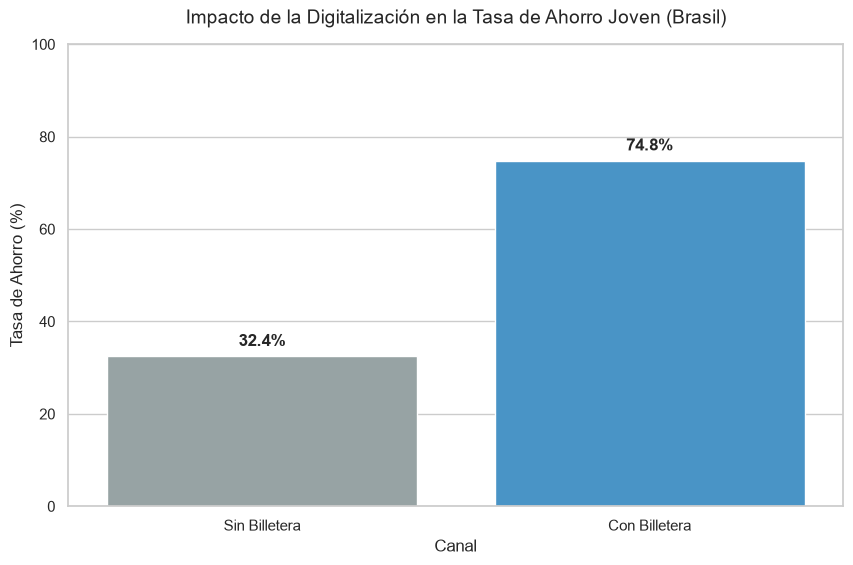

In [19]:
# Definición de segmentos digitales
# Según metadata: 0 = No, 1 = Sí.
n_antes = len(df_jov_br)
n_nulos_mob = df_jov_br['account_mob'].isna().sum()
print(f"Registros sin dato de 'account_mob': {n_nulos_mob} de {n_antes} ({n_nulos_mob/n_antes:.1%})")
print("Se excluyen del análisis del Digital Premium por falta de dato, no se asume 'No' por defecto.")

df_jov_br = df_jov_br.dropna(subset=['account_mob']).copy()
df_jov_br['es_digital'] = df_jov_br['account_mob'].astype(int)

# Cálculo del "Digital Premium" ponderado
tasa_ahorro_digital = (df_jov_br[df_jov_br['es_digital'] == 1]['ahorro_binario'] * \
                       df_jov_br[df_jov_br['es_digital'] == 1]['wgt']).sum() / \
                      df_jov_br[df_jov_br['es_digital'] == 1]['wgt'].sum()

tasa_ahorro_tradicional = (df_jov_br[df_jov_br['es_digital'] == 0]['ahorro_binario'] * \
                           df_jov_br[df_jov_br['es_digital'] == 0]['wgt']).sum() / \
                          df_jov_br[df_jov_br['es_digital'] == 0]['wgt'].sum()

premium_digital = tasa_ahorro_digital - tasa_ahorro_tradicional

print(f"\n--- Impacto del Ecosistema Digital en Brasil ---")
print(f"Tasa de Ahorro (Con Billetera Digital): {tasa_ahorro_digital:.2%}")
print(f"Tasa de Ahorro (Sin Billetera Digital): {tasa_ahorro_tradicional:.2%}")
print(f"Impacto del Canal Digital: +{premium_digital*100:.2f} puntos porcentuales")

plt.figure(figsize=(10, 6))
grafico_data = pd.DataFrame({
    'Canal': ['Sin Billetera', 'Con Billetera'],
    'Tasa': [tasa_ahorro_tradicional * 100, tasa_ahorro_digital * 100]
})

ax =sns.barplot(data=grafico_data, x='Canal', y='Tasa', hue='Canal', palette=['#95a5a6', '#3498db'], legend=False)

[ax.bar_label(c, fmt='%.1f%%', padding=5, weight='bold') for c in ax.containers]

plt.title('Impacto de la Digitalización en la Tasa de Ahorro Joven (Brasil)', fontsize=14, pad=15)
plt.ylabel('Tasa de Ahorro (%)')
plt.ylim(0, 100)
plt.show()

### --- SÍNTESIS DE INSIGHTS CONDUCTUALES ---

**Insight 1: La Paradoja del Ahorro Joven (Facilitador Digital)**

**Patrón observado:** Los jóvenes brasileños registran una tasa de ahorro del **64.6%**. Este comportamiento varía fuertemente según el canal: quienes usan billeteras digitales presentan una tasa de ahorro del **74.76%**, frente a un **32.43%** de quienes operan fuera del ecosistema digital.

- **Interpretación conductual (hipótesis, no comprobada con estos datos):** El diferencial de **+42.33 puntos porcentuales** (*Digital Premium*) es consistente con el marco de **Contabilidad Mental** (*Mental Accounting*): las interfaces de Pix y billeteras digitales podrían transformar el ahorro en una meta saliente de corto plazo, reduciendo la percepción de sacrificio futuro. Al ser un análisis transversal, esta asociación no permite afirmar causalidad — no puede descartarse que el tipo de persona más proclive a ahorrar sea también más proclive a adoptar billeteras digitales (causalidad inversa o variable de confusión).

**Insight 2: La Brecha de Género Frente al Ingreso**

**Patrón observado:** La brecha de género es comparable en magnitud a la brecha por ingresos. Un hombre joven en el estrato más pobre (Q1) ahorra el **63.9%**, superando a una mujer joven del estrato más rico (Q5), que alcanza el **53.2%**.

- **Interpretación conductual (hipótesis, no comprobada con estos datos):** Este patrón es consistente con una posible **fricción por sobrecarga cognitiva** en la administración del hogar, un mecanismo documentado en la literatura de economía conductual — pero el dataset no incluye variables de carga de trabajo doméstico ni uso del tiempo, por lo que esta es una explicación plausible a validar, no un hallazgo medido directamente.

**Insight 3: Inercia y Sesgo de Statu Quo (Barrera de Fricción)**

**Patrón observado:** En el sector de menores ingresos, la brecha de género es de **17.7 puntos**, pero en el sector más rico se dispara a **38.3 puntos** de diferencia.

- **Interpretación conductual (hipótesis, no comprobada con estos datos):** Este patrón sería consistente con un **Sesgo de Statu Quo** — el sistema actual podría ser más eficiente para capturar el ahorro masculino sin ofrecer una "salida por defecto" equivalente para la mujer. Al no contar con datos sobre el diseño de producto o el comportamiento de decisión, esto se plantea como hipótesis a testear, no como conclusión del análisis.

> **Nota de robustez:** Los porcentajes por celda (quintil × género) provienen de subgrupos de distinto tamaño muestral (ver conteos en la sección 03). Las diferencias más grandes (como Q5) deben leerse como una tendencia direccional respaldada por el patrón general, no como una cifra de precisión estadística garantizada.

## 05_Conclusiones y Recomendaciones

📊 **1. Síntesis de Hallazgos (Evidencia de Microdatos)**

Tras reconstruir el análisis utilizando registros individuales y ponderación poblacional (`wgt`), se identifican tres patrones críticos en el comportamiento de ahorro de la juventud brasileña (15-24 años):

- **Brecha de Género:** Existe una brecha de **28.27%** en la tasa de ahorro entre hombres y mujeres jóvenes, de magnitud comparable a la brecha por ingresos (**30.78%**). Esto indica que el género está tan asociado a la probabilidad de ahorro como el nivel socioeconómico, en esta muestra.
- **El "Digital Premium":** Los jóvenes con billeteras móviles presentan una tasa de ahorro del **74.76%**, frente a un **32.43%** de quienes operan fuera del ecosistema digital — una diferencia de **+42.33 puntos porcentuales**, el hallazgo más marcado de este análisis.
- **Naturaleza de la asociación:** Estas diferencias son correlacionales, medidas en un corte transversal. No es posible, con estos datos, establecer que el uso de billetera digital *causa* el ahorro, ni que el género *causa* la brecha por sí solo — ambas podrían estar mediadas por variables no observadas (acceso, tipo de empleo, carga de trabajo doméstico, etc.).

🧠 **2. Interpretación Conductual (hipótesis a validar, no conclusiones del dataset)**

- **Posible Sobrecarga Cognitiva (Brecha de Género):** Una hipótesis compatible con la literatura de economía conductual es que las mujeres, al administrar con mayor frecuencia los micro-gastos del hogar, enfrentan mayor carga de gestión manual del ahorro. El dataset no mide esta variable directamente, por lo que se plantea como línea a investigar, no como causa confirmada.
- **Posible Sesgo de Statu Quo (Exclusión):** El grupo que no ahorra en canal tradicional (32.43%) podría estar sujeto a la fricción de dar el primer paso sin un mecanismo por defecto. Igual que el punto anterior, es una hipótesis razonable, no un hallazgo medido.

💡 **3. Recomendación Estratégica: "Redondeo Pix"**

Dado el tamaño del Digital Premium (+42 puntos) y la brecha de género observada, se propone explorar una solución de **Redondeo Automático Integrado en Pix**.

- **Acción Concreta:** Transformar cada transacción cotidiana en un mecanismo de ahorro. Si una usuaria gasta 25.50 BRL, el sistema redondea al entero superior y desvía los 0.50 BRL restantes a una "Caixinha" de ahorro remunerada.
- **Arquitectura de Decisión:** La solución utiliza una **Regla por Defecto** (*Default Option*), reduciendo la necesidad de decisión manual repetida.
- **Impacto Esperado:** No contamos con datos de adopción o retención de un producto de este tipo — el 74.76% observado corresponde a tasa de ahorro general de usuarios de billetera digital, no a retención de una feature de auto-redondeo, por lo que no es una base válida para proyectar una cifra de retención específica. Se recomienda validar el impacto real mediante un **piloto controlado (A/B)** antes de proyectar tasas de adopción o retención.

⚠️ **4. Limitaciones**

- Las tasas por celda (quintil × género) se basan en subgrupos de tamaño desigual; los resultados más extremos deben tomarse como señal direccional.
- Se excluyeron del análisis del Digital Premium los registros sin dato de `account_mob`, para no asumir un valor por defecto que no está en los datos.
- El análisis es transversal (un punto en el tiempo): no permite afirmar causalidad entre uso de billetera digital y ahorro, ni entre género y ahorro, solo asociación.
- Las interpretaciones conductuales (contabilidad mental, sobrecarga cognitiva, sesgo de statu quo) son hipótesis razonadas a partir de la literatura, no hallazgos medidos directamente en este dataset — se recomienda validación adicional (encuestas de uso del tiempo, testeo A/B del producto propuesto) antes de tomarlas como base de decisión.